Import  needed libraries 

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.datasets import make_moons , make_circles
from sklearn.metrics import confusion_matrix ,ConfusionMatrixDisplay , precision_score , recall_score , roc_auc_score , f1_score
import matplotlib.pyplot as plt

Creating the Madaline class

In [ ]:
class Madaline():
    def __init__(self , m ,learning_rate = 0.001):
        np.random.seed(0)
        self.m = m
        self.lr = learning_rate
        self.SSE_list = []
        self.score_list = []
        
    def fit (self , x , y ,x_val , y_val):
        self.X_train = x
        self.num_of_sample , self.num_of_features = x.shape 
        self.Y_train = y
        self.w=np.random.randn(self.num_of_features,self.m) * 0.1
        self.bias = np.zeros(self.m)
        self.x_val = x_val
        self.y_val = y_val
    
    def calculate(self, x):
        z = np.where(x @ self.w + self.bias >= 0, 1, -1)
        return 1 if np.all(z == 1) else -1  
    
    def find_candidate(self, x):
        nets = x @ self.w + self.bias
        z = np.sign(nets)
        out = 1 if np.mean(z) >= 0 else -1
        wrong_idx = np.where(z != out)[0]
    
        if len(wrong_idx) == 0:
            return None
        c = wrong_idx[np.argmin(np.abs(nets[wrong_idx]))]
        return c

    def train (self , num_of_epoch=100 , landa = 0):
        for epoch in range(num_of_epoch):
            SSE = 0
            for i in range (self.num_of_sample):
                y_pred = self.calculate(self.X_train[i])
                SSE += (y_pred - self.Y_train[i])**2
                if y_pred != self.Y_train[i] :
                    c = self.find_candidate(self.X_train[i])
                    
                    if c is None:
                        continue
                    net= float(self.X_train[i] @ self.w[:,c] +self.bias[c])
                    
                    self.w[:, c] += self.lr * ((self.Y_train[i] - net) * self.X_train[i] - landa * self.w[:, c])
                    self.bias[c] = self.bias[c] + self.lr *((self.Y_train[i] - net) - landa *  self.bias[c])
            
            
            y_pred = self.predict(self.x_val)
            score = Eval(y_pred , self.y_val )
            self.score_list.append(score)
            self.SSE_list.append(SSE)

        
        return self.SSE_list ,self.score_list 
            
            

        
    def predict(self, X):
        preds = []
        for x in X:
            preds.append(self.calculate(x))
        return np.array(preds)
    



def Eval (Y_pred , Y_true):
    score = np.equal(Y_pred , Y_true)
    score = np.sum(score)/len(Y_true)
    return score
        
    
    




With make_moon and make_circle we create our datas and normalizing them

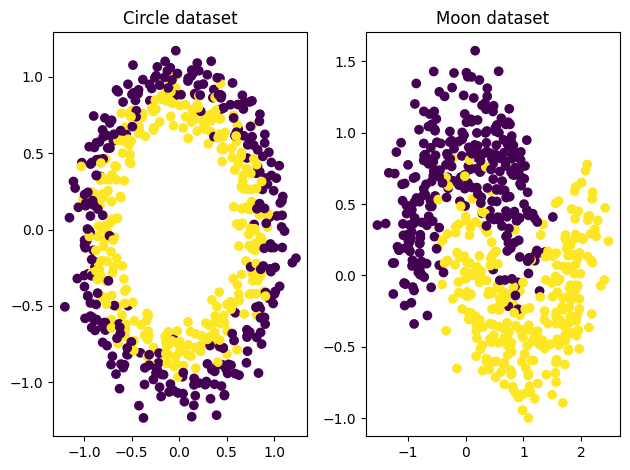

In [92]:
x_moon ,y_moon = make_moons(n_samples=600 , noise=0.25 , random_state = 0)
x_circle , y_circle = make_circles(n_samples=600 , noise=0.1 , random_state = 0)

plt.subplot(1,2,1)
plt.scatter(x_circle[:,0] , x_circle[:,1] , c=y_circle )
plt.title("Circle dataset")

plt.subplot(1,2,2)
plt.scatter(x_moon[:,0] , x_moon[:,1] , c=y_moon )
plt.title("Moon dataset")

plt.tight_layout()
plt.show()

y_moon=np.array([-1 if i==0 else 1 for i in y_moon])
y_circle=np.array([-1 if i==0 else 1 for i in y_circle])

xm_temp , xm_test , ym_temp , ym_test = train_test_split(x_moon , y_moon , test_size=0.3 , shuffle=True , random_state=0 , stratify= y_moon)
xm_train , xm_val , ym_train , ym_val = train_test_split(xm_temp , ym_temp , test_size=0.2 , shuffle=True , random_state=0 , stratify= ym_temp)

xc_temp , xc_test , yc_temp , yc_test = train_test_split(x_circle , y_circle , test_size=0.3 , shuffle=True , random_state=0 ,stratify= y_circle)
xc_train , xc_val , yc_train , yc_val = train_test_split(xc_temp , yc_temp , test_size=0.2 , shuffle=True , random_state=0 , stratify= yc_temp)


scaler = StandardScaler()
xc_train = scaler.fit_transform(xc_train)
xc_test = scaler.transform(xc_test)
xc_val = scaler.transform(xc_val)

xm_train = scaler.fit_transform(xm_train)
xm_test = scaler.transform(xm_test)
xm_val = scaler.transform(xm_val)



At this stage, we change the hyperparameters to identify the best-performing model for Moon datas. ( 3 or 5 units and 0 or 0.001 L2 regularization )

In [ ]:
num_of_epoch = 100

model = Madaline(3)
model.fit(xm_train, ym_train ,xm_val ,ym_val  )
sse30, score30=model.train(num_of_epoch ,landa = 0)
ym_pred = model.predict(xm_test)
error = Eval(ym_pred , ym_test)
print(error)

model = Madaline(3)
model.fit(xm_train, ym_train ,xm_val ,ym_val )
sse31, score31=model.train(num_of_epoch ,landa = 0.001)
ym_pred = model.predict(xm_test)
error = Eval(ym_pred , ym_test)
print(error)

model = Madaline(5)
model.fit(xm_train, ym_train ,xm_val ,ym_val )
sse50, score50=model.train(num_of_epoch ,landa = 0)
ym_pred = model.predict(xm_test)
error = Eval(ym_pred , ym_test)
print(error)

model = Madaline(5)
model.fit(xm_train, ym_train ,xm_val ,ym_val )
sse51, score51=model.train(num_of_epoch ,landa = 0.001)
ym_pred = model.predict(xm_test)
error = Eval(ym_pred , ym_test)
print(error)



0.3388888888888889
0.3388888888888889
0.7833333333333333
0.7833333333333333


Selecting the best model

In [94]:
model = Madaline(5)
model.fit(xm_train, ym_train ,xm_val ,ym_val )
model.train(num_of_epoch ,landa = 0.001)
ym_pred = model.predict(xm_test)

We can plot the results

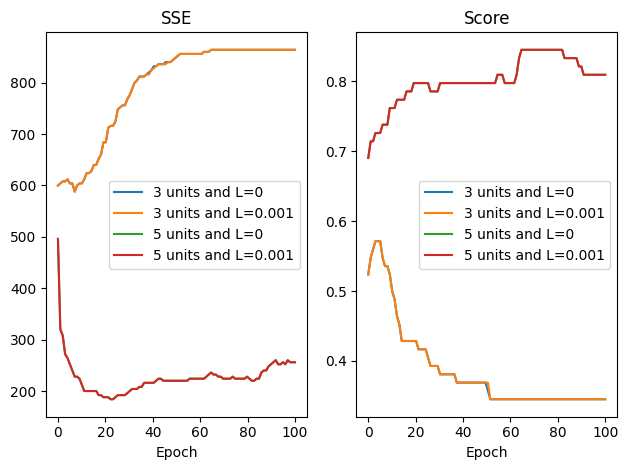

In [95]:
Epochs = np.linspace(0,num_of_epoch,num_of_epoch)

plt.subplot(1,2,1)
plt.plot(Epochs , sse30 ,label = '3 units and L=0')
plt.plot(Epochs , sse31 ,label = '3 units and L=0.001')
plt.plot(Epochs , sse50 ,label = '5 units and L=0')
plt.plot(Epochs , sse51 ,label = '5 units and L=0.001')
plt.legend()
plt.title("SSE")
plt.xlabel("Epoch")

plt.subplot(1,2,2)
plt.plot(Epochs ,score30 , label = '3 units and L=0')
plt.plot(Epochs ,score31 , label = '3 units and L=0.001')
plt.plot(Epochs ,score50 , label = '5 units and L=0')
plt.plot(Epochs ,score51 , label = '5 units and L=0.001')
plt.legend()
plt.title("Score")
plt.xlabel("Epoch")

plt.tight_layout()
plt.show()

Evaulate the best model

precision 0.718 :
recall 0.933 : 
ROC_AUC 0.783: 
F1 : 0.812


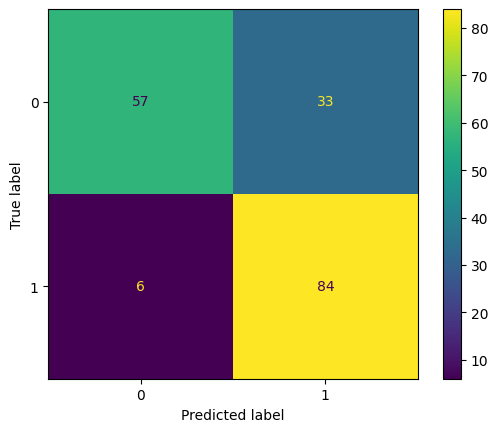

In [96]:
cm = confusion_matrix(ym_test , ym_pred)

precision = precision_score(ym_test ,ym_pred)
recall = recall_score(ym_test , ym_pred)
roc_auc =roc_auc_score(ym_test , ym_pred)
f1 = f1_score(ym_test , ym_pred)


print(f"precision {precision:.3f} :" )
print(f"recall {recall:.3f} : ")
print(f"ROC_AUC {roc_auc:.3f}: " , )
print(f"F1 : {f1:.3f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

Next , We show the Madaline disicion boundraies

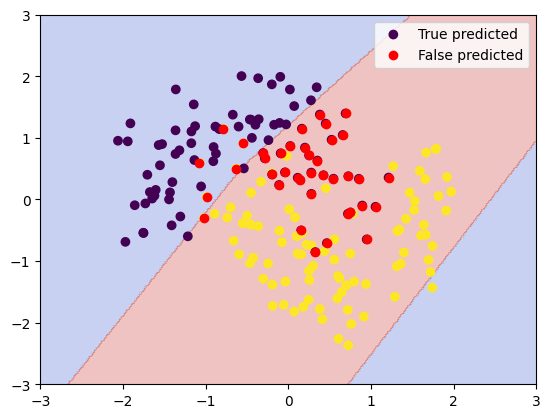

In [97]:
xm_test = scaler.fit_transform(xm_test)
false = np.where(ym_pred != ym_test)
xm_false = xm_test[false]

X_space = np.linspace(-3 , 3, 300)
Y_space = np.linspace(-3 , 3 , 300)

xx, yy = np.meshgrid(X_space , Y_space)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

plt.scatter(xm_test[:,0] , xm_test[:,1] , c=ym_test , label = 'True predicted')
plt.scatter(xm_false[:,0] , xm_false[:,1] , c='red' , label = 'False predicted')

plt.ylim(-3,3)
plt.legend()
plt.show()

We'll do the same for the Circles dataset

In [ ]:
num_of_epoch = 100

model = Madaline(15)
model.fit(xc_train, yc_train ,xc_val ,yc_val )
sse30, score30=model.train(num_of_epoch ,landa = 0.001)
yc_pred = model.predict(xc_test)
error = Eval(yc_pred , yc_test)
print(error)

model = Madaline(15)
model.fit(xc_train, yc_train ,xc_val ,yc_val )
sse31, score31=model.train(num_of_epoch ,landa = 0.001)
yc_pred = model.predict(xc_test)
error = Eval(yc_pred , yc_test)
print(error)

model = Madaline(30)
model.fit(xc_train, yc_train ,xc_val ,yc_val )
sse50, score50=model.train(num_of_epoch ,landa = 0)
yc_pred = model.predict(xc_test)
error = Eval(yc_pred , yc_test)
print(error)

model = Madaline(30)
model.fit(xc_train, yc_train ,xc_val ,yc_val )
sse51, score51=model.train(num_of_epoch ,landa = 0.001)
yc_pred = model.predict(xc_test)
error = Eval(yc_pred , yc_test)
print(error)

0.6055555555555555
0.6055555555555555
0.7611111111111111
0.7722222222222223


Selecting the best model

In [99]:
model = Madaline(30)
model.fit(xc_train, yc_train ,xc_val ,yc_val )
model.train(num_of_epoch ,landa = 0.001)
yc_pred = model.predict(xc_test)

Plots

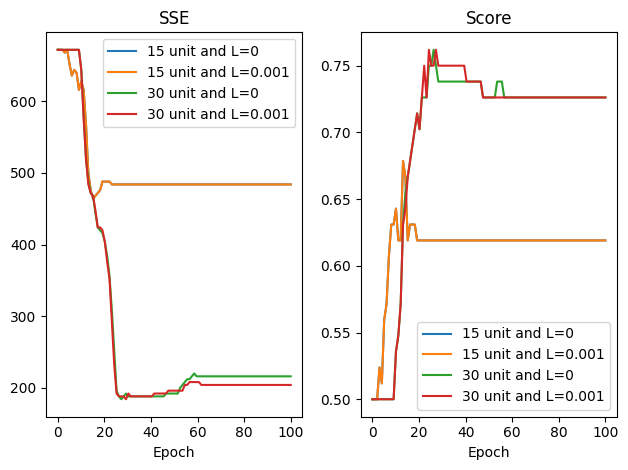

In [100]:
Epochs = np.linspace(0,num_of_epoch,num_of_epoch)

plt.subplot(1,2,1)
plt.plot(Epochs , sse30 ,label = '15 unit and L=0')
plt.plot(Epochs , sse31 ,label = '15 unit and L=0.001')
plt.plot(Epochs , sse50 ,label = '30 unit and L=0')
plt.plot(Epochs , sse51 ,label = '30 unit and L=0.001')
plt.legend()
plt.title("SSE")
plt.xlabel("Epoch")

plt.subplot(1,2,2)
plt.plot(Epochs ,score30 , label = '15 unit and L=0')
plt.plot(Epochs ,score31 , label = '15 unit and L=0.001')
plt.plot(Epochs ,score50 , label = '30 unit and L=0')
plt.plot(Epochs ,score51 , label = '30 unit and L=0.001')
plt.legend()
plt.title("Score")
plt.xlabel("Epoch")

plt.tight_layout()
plt.show()

Evaluate the best model

precision 0.699 :
recall 0.956 : 
ROC_AUC 0.772: 
F1 : 0.808


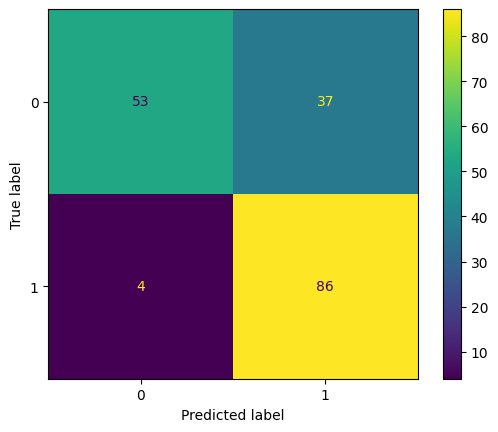

In [101]:
cm = confusion_matrix(yc_test , yc_pred)

precision = precision_score(yc_test ,yc_pred)
recall = recall_score(yc_test , yc_pred)
roc_auc =roc_auc_score(yc_test , yc_pred)
f1 = f1_score(yc_test , yc_pred)


print(f"precision {precision:.3f} :" )
print(f"recall {recall:.3f} : ")
print(f"ROC_AUC {roc_auc:.3f}: " , )
print(f"F1 : {f1:.3f}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

Madaline dicision boundries

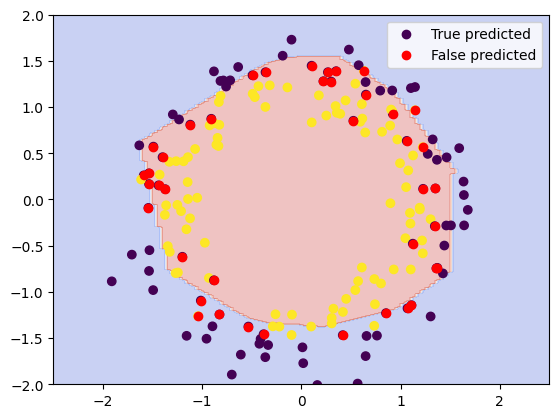

In [102]:
xc_test = scaler.fit_transform(xc_test)

false = np.where(yc_pred != yc_test)
xc_false = xc_test[false]

X_space = np.linspace(- 2.5 , 2.5 , 100)
Y_space = np.linspace(-2 , 2 , 300)

xx, yy = np.meshgrid(X_space , Y_space)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

plt.scatter(xc_test[:,0] , xc_test[:,1] , c=yc_test , label = "True predicted")
plt.scatter(xc_false[:,0] , xc_false[:,1] , c='red' , label = "False predicted")
plt.ylim(-2,2)
plt.legend()
plt.show()
